# Modelling

## Design decisions

Divided each country's satellite imagery into 64x64 pixel patches, ending up with 1,044 patches across all six countries. Each patch contains six input channels: four years of VIIRS nightlight data (2013 to 2016), a binary indicator of whether the area is classified as built-up by ESA WorldCover, and log-transformed population density from GHSL. We deliberately excluded the 2017 nightlight band because the outcome we are trying to predict is derived from the 2013 to 2017 change, so including it would let the model cheat.

To label each patch, we computed the percentage change in nightlight between 2013 and 2017 and split patches into three equal groups within each country: Low, Medium, and High growth. Doing this separately per country ensures that each class has roughly the same number of patches regardless of how fast or slow a given country grew overall.

The model is a 4-block CNN where each block applies convolution, batch normalisation, and spatial dropout before pooling. We used AdamW as the optimiser with a cosine learning rate schedule and stopped training early when validation loss stopped improving. To make the most of our limited training data, we augmented each patch with random flips and rotations during training.

We evaluated using leave-one-country-out cross-validation: train on five countries, test on the sixth, and repeat for each country. Normalization statistics were recomputed from scratch in each fold using only the training countries to avoid any leakage. We compared the CNN against a logistic regression baseline that uses only the average brightness per channel rather than the full spatial patch.


## Imports and constants

In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path

PATCH_DIR = Path("data/patches")
COUNTRIES = [
    "Albania",
    "Bosnia_and_Herzegovina",
    "Kosovo",
    "Montenegro",
    "North_Macedonia",
    "Serbia",
]

# VIIRS 2013–2016 (0–3) + built-up (5) + pop (6) — drop VIIRS 2017 (4) to avoid leakage
INPUT_CHANNELS = [0, 1, 2, 3, 5, 6]
N_CLASSES      = 3
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## Load patches

In [23]:
all_patches = {}
all_labels  = {}

for country in COUNTRIES:
    patches = np.load(PATCH_DIR / f"{country}_patches.npy")[:, INPUT_CHANNELS, :, :].astype(np.float32)
    labels  = np.load(PATCH_DIR / f"{country}_labels.npy").astype(np.int64)
    all_patches[country] = patches
    all_labels[country]  = labels
    print(f"{country}: {patches.shape} | class counts {np.bincount(labels)}")

Albania: (92, 6, 64, 64) | class counts [31 30 31]
Bosnia_and_Herzegovina: (236, 6, 64, 64) | class counts [78 80 78]
Kosovo: (73, 6, 64, 64) | class counts [24 25 24]
Montenegro: (47, 6, 64, 64) | class counts [16 15 16]
North_Macedonia: (80, 6, 64, 64) | class counts [27 26 27]
Serbia: (516, 6, 64, 64) | class counts [170 176 170]


## Dataset and DataLoaders

In [24]:
def augment_patch(patch):
    if np.random.random() > 0.5:
        patch = np.flip(patch, axis=2).copy()          # horizontal flip
    if np.random.random() > 0.5:
        patch = np.flip(patch, axis=1).copy()          # vertical flip
    k = np.random.randint(0, 4)
    if k > 0:
        patch = np.rot90(patch, k=k, axes=(1, 2)).copy()  # 90/180/270 rotation
    return patch


class PatchDataset(Dataset):
    def __init__(self, patches, labels, mean, std, augment=False):
        self.patches = patches
        self.labels  = labels
        self.augment = augment
        self.mean    = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std     = torch.tensor(std,  dtype=torch.float32).view(-1, 1, 1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = self.patches[idx].copy()
        if self.augment:
            patch = augment_patch(patch)
        x = (torch.tensor(patch, dtype=torch.float32) - self.mean) / (self.std + 1e-8)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def make_loaders(test_country, batch_size=32, val_frac=0.2, seed=42):
    train_countries = [c for c in COUNTRIES if c != test_country]

    tr_patches = np.concatenate([all_patches[c] for c in train_countries])
    tr_labels  = np.concatenate([all_labels[c]  for c in train_countries])

    # normalization computed on training countries only
    mean = tr_patches.mean(axis=(0, 2, 3))
    std  = tr_patches.std(axis=(0, 2, 3))

    tr_p, val_p, tr_l, val_l = train_test_split(
        tr_patches, tr_labels, test_size=val_frac, random_state=seed, stratify=tr_labels
    )

    train_loader = DataLoader(PatchDataset(tr_p,  tr_l,  mean, std, augment=True),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(PatchDataset(val_p, val_l, mean, std, augment=False),
                              batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(PatchDataset(all_patches[test_country], all_labels[test_country],
                              mean, std, augment=False),
                              batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


# sanity check
tr, val, te = make_loaders("Kosovo")
print(f"Train batches: {len(tr)} | Val batches: {len(val)} | Test batches: {len(te)}")

Train batches: 25 | Val batches: 7 | Test batches: 3


## CNN architecture

In [25]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )

    def forward(self, x):
        return self.block(x)


class NightlightCNN(nn.Module):
    def __init__(self, in_channels=6, n_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32),   # 64×64 → 32×32
            ConvBlock(32, 64),            # 32×32 → 16×16
            ConvBlock(64, 128),           # 16×16 → 8×8
            ConvBlock(128, 256),          # 8×8   → 4×4
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)  # 4×4 → 1×1
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)


# sanity check
dummy = torch.zeros(4, 6, 64, 64)
print("Output shape:", NightlightCNN()(dummy).shape)  # expect torch.Size([4, 3])

Output shape: torch.Size([4, 3])


## Training function

In [26]:
def train_fold(test_country, epochs=80, lr=1e-3, patience=15):
    train_loader, val_loader, test_loader = make_loaders(test_country)

    model     = NightlightCNN(in_channels=len(INPUT_CHANNELS), n_classes=N_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss    = float("inf")
    patience_counter = 0
    best_state       = None
    history          = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                val_loss += criterion(model(X), y).item() * len(y)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch + 1}")
                break

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for X, y in test_loader:
            logits = model(X.to(DEVICE))
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_true.append(y.numpy())

    y_true  = np.concatenate(all_true)
    y_pred  = np.concatenate(all_preds)
    y_probs = np.concatenate(all_probs)

    return {
        "country":  test_country,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1":       f1_score(y_true, y_pred, average="weighted"),
        "auc":      roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro"),
        "cm":       confusion_matrix(y_true, y_pred),
        "history":  history,
        "n_test":   len(y_true),
        "y_true":   y_true,
        "y_pred":   y_pred,
        "y_probs":  y_probs,
    }

## LOOCV loop

In [38]:
import pickle, os

if os.path.exists("data/loocv_results.pkl"):
    with open("data/loocv_results.pkl", "rb") as f:
        results = pickle.load(f)
    print("Loaded saved results.")
else:
    torch.manual_seed(42)
    np.random.seed(42)
    results = []
    for country in COUNTRIES:
        print(f"\n--- Fold: test on {country} ---")
        r = train_fold(country)
        results.append(r)
        print(f"  Accuracy: {r['accuracy']:.3f}  F1: {r['f1']:.3f}  AUC: {r['auc']:.3f}  (n={r['n_test']})")
    with open("data/loocv_results.pkl", "wb") as f:
        pickle.dump(results, f)
    print("Saved results.")

Loaded saved results.


## Results summary

In [28]:
rows = [{
    "Country":   r["country"].replace("_", " "),
    "N test":    r["n_test"],
    "Accuracy":  round(r["accuracy"], 3),
    "F1 (wtd)":  round(r["f1"],       3),
    "AUC (ovr)": round(r["auc"],      3),
} for r in results]

df = pd.DataFrame(rows)
mean_row = {
    "Country":   "Mean",
    "N test":    "—",
    "Accuracy":  round(df["Accuracy"].mean(),  3),
    "F1 (wtd)":  round(df["F1 (wtd)"].mean(),  3),
    "AUC (ovr)": round(df["AUC (ovr)"].mean(), 3),
}
df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
print(df.to_string(index=False))

               Country N test  Accuracy  F1 (wtd)  AUC (ovr)
               Albania     92     0.587     0.558      0.839
Bosnia and Herzegovina    236     0.559     0.567      0.765
                Kosovo     73     0.616     0.604      0.820
            Montenegro     47     0.447     0.364      0.626
       North Macedonia     80     0.650     0.659      0.842
                Serbia    516     0.560     0.557      0.744
                  Mean      —     0.570     0.552      0.773


## Confusion matrices

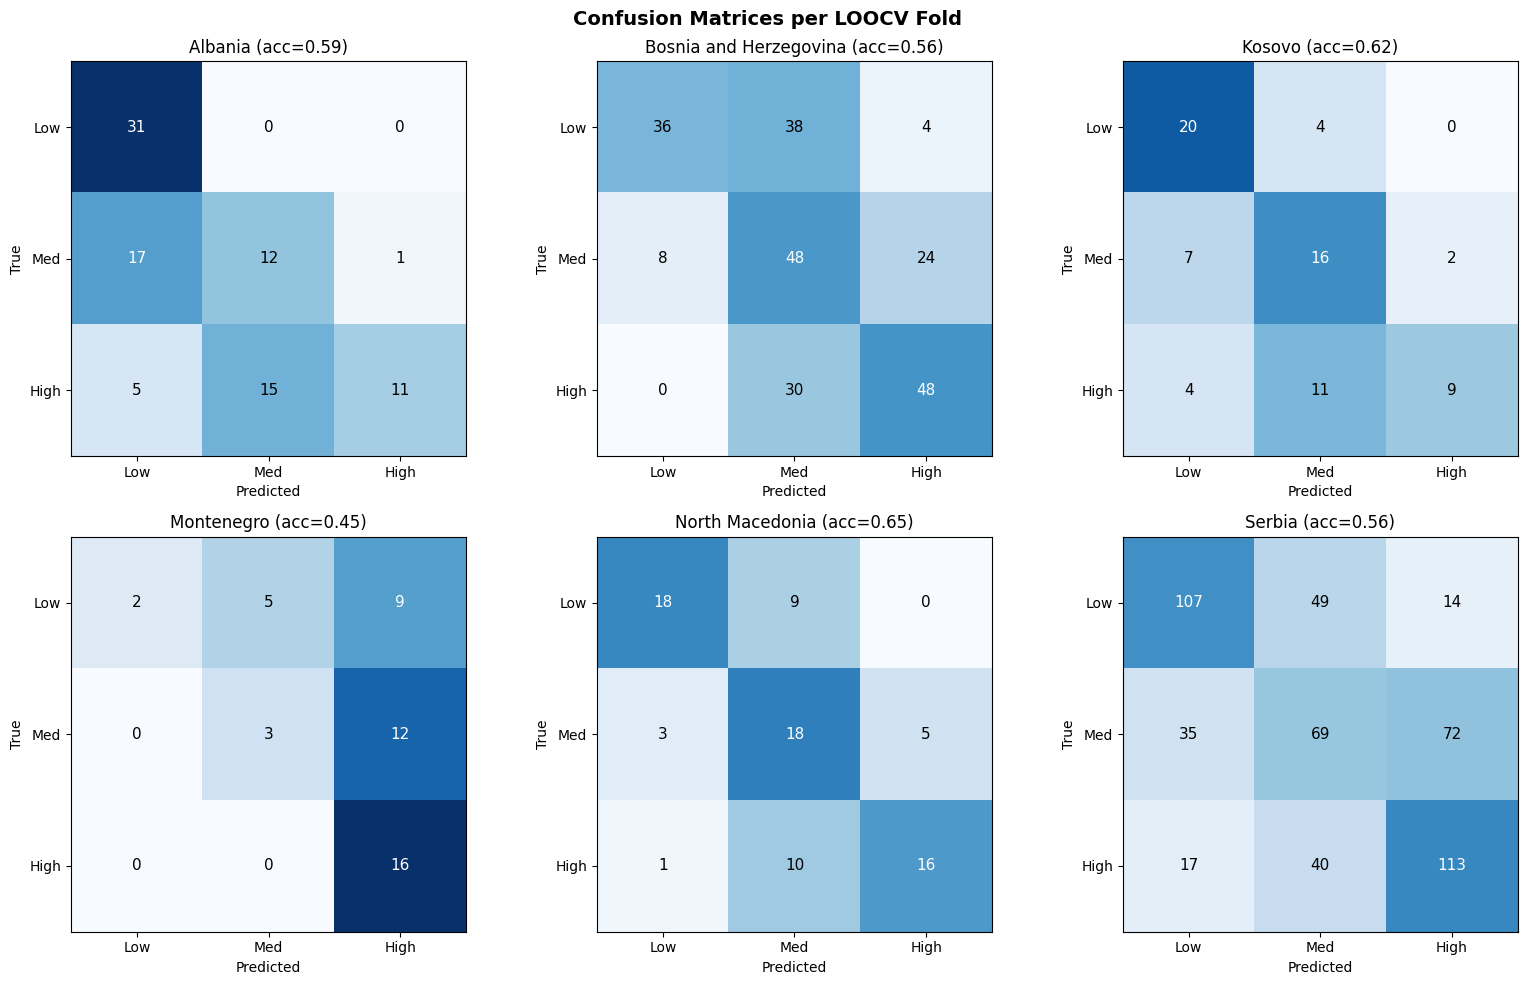

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Confusion Matrices per LOOCV Fold", fontsize=14, fontweight="bold")
class_names = ["Low", "Med", "High"]

for ax, r in zip(axes.flat, results):
    cm      = r["cm"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(class_names)
    ax.set_yticks(range(3)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{r['country'].replace('_', ' ')} (acc={r['accuracy']:.2f})")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=11)

plt.tight_layout()
plt.show()

## Loss curves

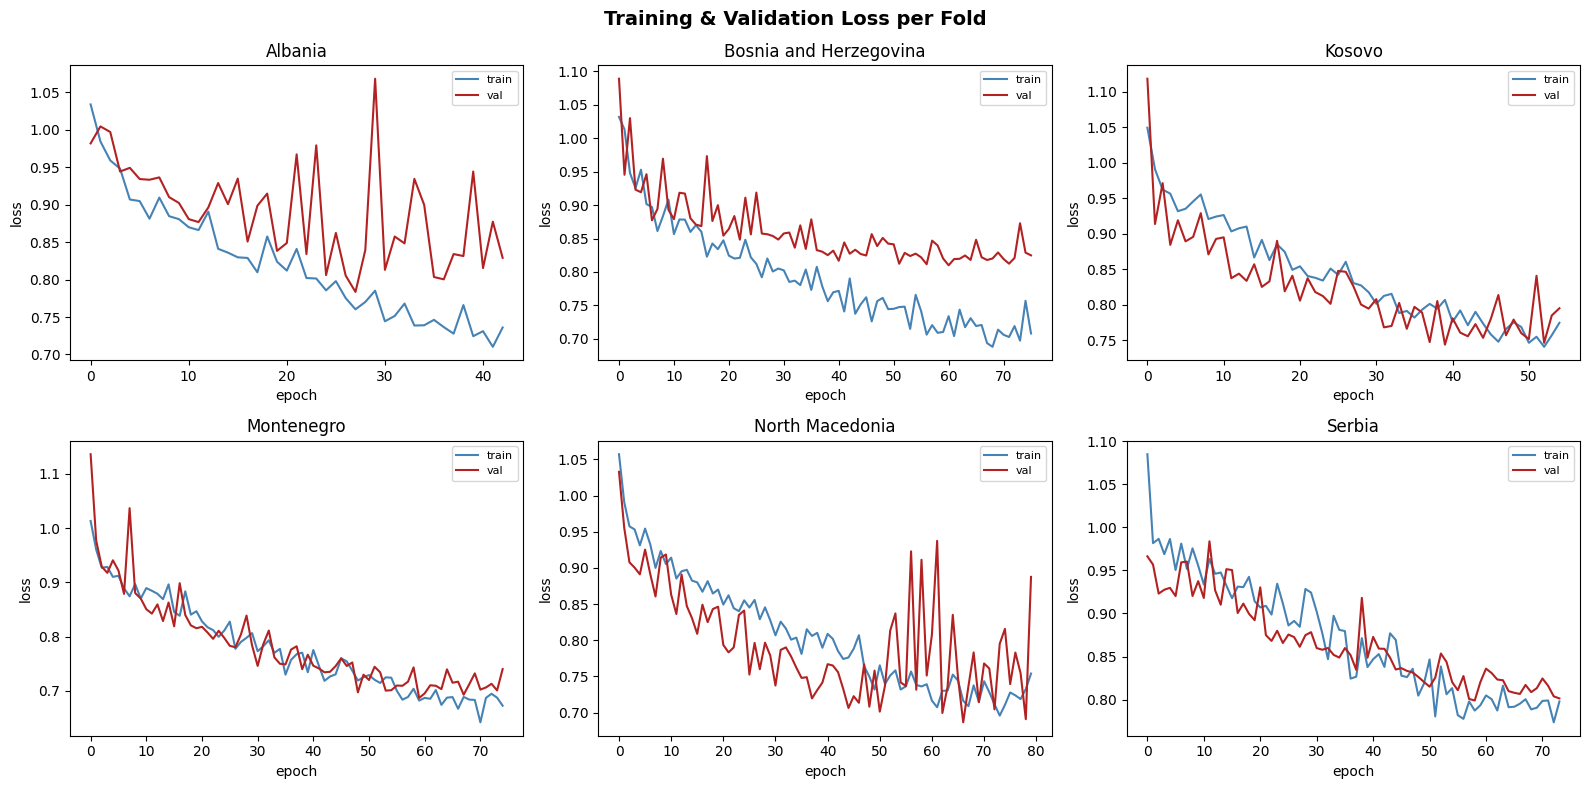

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Training & Validation Loss per Fold", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, results):
    ax.plot(r["history"]["train_loss"], label="train", color="steelblue")
    ax.plot(r["history"]["val_loss"],   label="val",   color="firebrick")
    ax.set_title(r["country"].replace("_", " "))
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Logistic baseline

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

baseline_results = []
for country in COUNTRIES:
    train_countries = [c for c in COUNTRIES if c != country]
    tr_p = np.concatenate([all_patches[c] for c in train_countries])
    tr_l = np.concatenate([all_labels[c]  for c in train_countries])
    te_p = all_patches[country]
    te_l = all_labels[country]

    X_train = tr_p.mean(axis=(2, 3))
    X_test  = te_p.mean(axis=(2, 3))
    scaler  = StandardScaler().fit(X_train)
    clf     = LogisticRegression(max_iter=1000, random_state=42).fit(scaler.transform(X_train), tr_l)

    y_pred  = clf.predict(scaler.transform(X_test))
    y_probs = clf.predict_proba(scaler.transform(X_test))
    baseline_results.append({
        "Country":      country.replace("_", " "),
        "LR Accuracy":  round(accuracy_score(te_l, y_pred), 3),
        "LR AUC":       round(roc_auc_score(te_l, y_probs, multi_class="ovr", average="macro"), 3),
    })

lr_df  = pd.DataFrame(baseline_results)
cnn_df = pd.DataFrame([{
    "Country":      r["country"].replace("_", " "),
    "CNN Accuracy": round(r["accuracy"], 3),
    "CNN AUC":      round(r["auc"], 3),
} for r in results])

cmp = cnn_df.merge(lr_df, on="Country")
cmp["Acc gain"] = (cmp["CNN Accuracy"] - cmp["LR Accuracy"]).round(3)
cmp["AUC gain"] = (cmp["CNN AUC"]      - cmp["LR AUC"]).round(3)

mean_row = {
    "Country": "Mean",
    "CNN Accuracy": cmp["CNN Accuracy"].mean().round(3),
    "CNN AUC":      cmp["CNN AUC"].mean().round(3),
    "LR Accuracy":  cmp["LR Accuracy"].mean().round(3),
    "LR AUC":       cmp["LR AUC"].mean().round(3),
    "Acc gain":     cmp["Acc gain"].mean().round(3),
    "AUC gain":     cmp["AUC gain"].mean().round(3),
}
cmp = pd.concat([cmp, pd.DataFrame([mean_row])], ignore_index=True)
print(cmp.to_string(index=False))

               Country  CNN Accuracy  CNN AUC  LR Accuracy  LR AUC  Acc gain  AUC gain
               Albania         0.587    0.839        0.565   0.775     0.022     0.064
Bosnia and Herzegovina         0.559    0.765        0.572   0.750    -0.013     0.015
                Kosovo         0.616    0.820        0.562   0.739     0.054     0.081
            Montenegro         0.447    0.626        0.319   0.492     0.128     0.134
       North Macedonia         0.650    0.842        0.500   0.763     0.150     0.079
                Serbia         0.560    0.744        0.463   0.684     0.097     0.060
                  Mean         0.570    0.773        0.497   0.700     0.073     0.072


## Per-patch results + worst-fold viz

Per-patch results (sorted by confidence, wrong predictions only):
        country  patch_idx  true  pred  confidence  correct
         Serbia        243     1     0       0.964    False
         Serbia        267     1     0       0.952    False
         Serbia        352     1     0       0.948    False
         Serbia        268     1     0       0.925    False
         Serbia        351     1     0       0.922    False
         Serbia        330     1     0       0.921    False
         Serbia        265     1     0       0.919    False
         Serbia        311     1     0       0.898    False
         Serbia        266     1     0       0.893    False
        Albania         15     1     0       0.879    False
North Macedonia         17     1     0       0.835    False
         Serbia        331     1     0       0.835    False
         Serbia        234     1     0       0.829    False
         Kosovo         71     1     0       0.805    False
         Serbia        181     1  

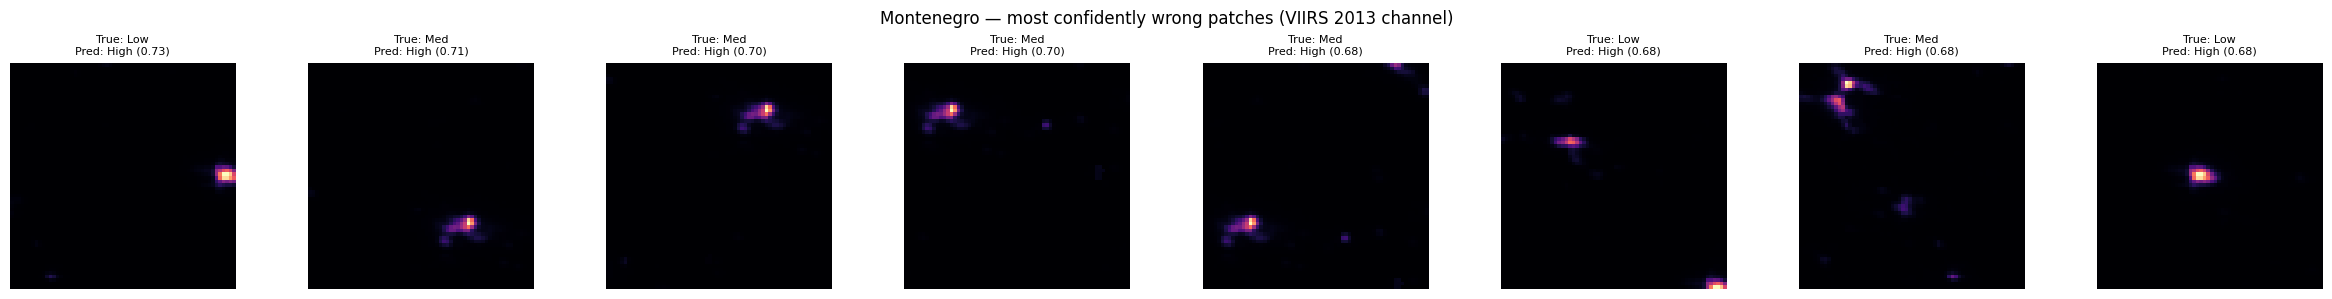

In [32]:
class_names = ["Low", "Med", "High"]

# build per-patch results DataFrame across all folds
records = []
for r in results:
    country = r["country"]
    for i, (true, pred, probs) in enumerate(zip(r["y_true"], r["y_pred"], r["y_probs"])):
        records.append({
            "country":    country.replace("_", " "),
            "patch_idx":  i,
            "true":       int(true),
            "pred":       int(pred),
            "confidence": round(float(probs.max()), 3),
            "correct":    bool(true == pred),
        })

patch_df = pd.DataFrame(records)
print("Per-patch results (sorted by confidence, wrong predictions only):")
print(patch_df[~patch_df["correct"]].sort_values("confidence", ascending=False).head(15).to_string(index=False))

# worst-fold patch visualization — Montenegro
worst = "Montenegro"
r_w   = next(r for r in results if r["country"] == worst)
wrong_idx = np.where(r_w["y_true"] != r_w["y_pred"])[0]
# sort by confidence descending (most confidently wrong)
wrong_conf = r_w["y_probs"][wrong_idx].max(axis=1)
wrong_idx  = wrong_idx[np.argsort(wrong_conf)[::-1]]

n_show  = min(8, len(wrong_idx))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
fig.suptitle(f"{worst} — most confidently wrong patches (VIIRS 2013 channel)", fontsize=12)

for ax, idx in zip(axes, wrong_idx[:n_show]):
    patch  = all_patches[worst][idx]
    true_l = class_names[r_w["y_true"][idx]]
    pred_l = class_names[r_w["y_pred"][idx]]
    conf   = r_w["y_probs"][idx].max()
    ax.imshow(patch[0], cmap="magma")   # VIIRS 2013
    ax.set_title(f"True: {true_l}\nPred: {pred_l} ({conf:.2f})", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## CNN vs LR bar chart

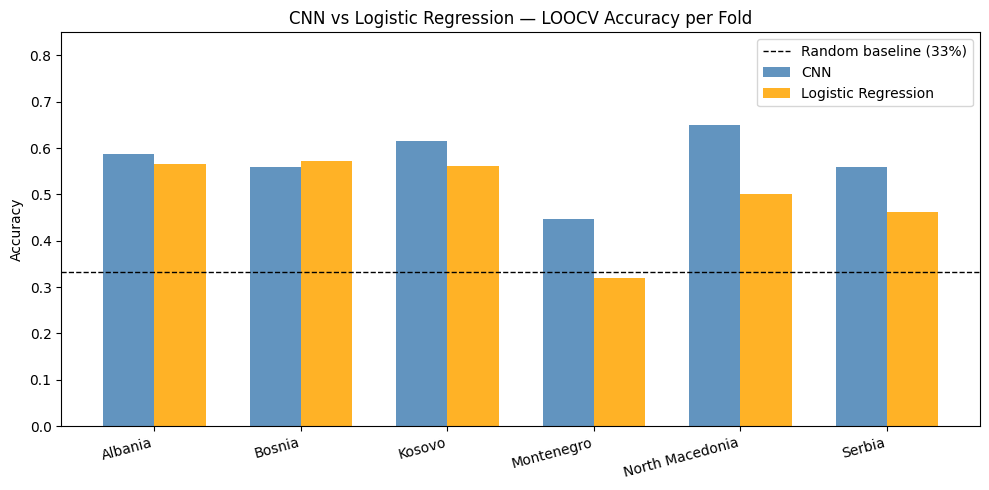

In [34]:
countries_short = [r["country"].replace("_", " ").replace("Bosnia and Herzegovina", "Bosnia") for r in results]
cnn_accs = [r["accuracy"] for r in results]
lr_accs  = [float(cmp[cmp["Country"] == r["country"].replace("_", " ")]["LR Accuracy"].values[0]) for r in results]

x     = np.arange(len(countries_short))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, cnn_accs, width, label="CNN",                color="steelblue", alpha=0.85)
ax.bar(x + width/2, lr_accs,  width, label="Logistic Regression", color="orange",    alpha=0.85)
ax.axhline(1/3, color="black", linestyle="--", linewidth=1, label="Random baseline (33%)")

ax.set_xticks(x)
ax.set_xticklabels(countries_short, rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("CNN vs Logistic Regression — LOOCV Accuracy per Fold")
ax.set_ylim(0, 0.85)
ax.legend()
plt.tight_layout()
plt.show()

## Confidence distribution

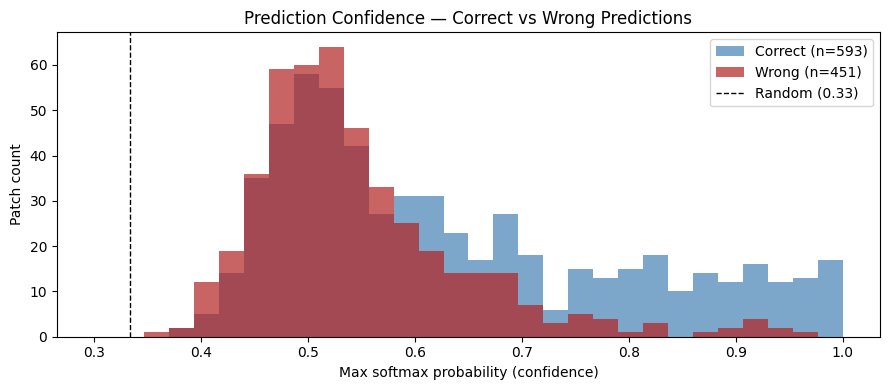

Mean confidence — correct: 0.635 | wrong: 0.546


In [35]:
all_conf_correct = []
all_conf_wrong   = []

for r in results:
    conf = r["y_probs"].max(axis=1)
    all_conf_correct.extend(conf[r["y_true"] == r["y_pred"]].tolist())
    all_conf_wrong.extend(conf[r["y_true"] != r["y_pred"]].tolist())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_conf_correct, bins=30, range=(0.3, 1.0), alpha=0.7, color="steelblue", label=f"Correct (n={len(all_conf_correct)})")
ax.hist(all_conf_wrong,   bins=30, range=(0.3, 1.0), alpha=0.7, color="firebrick", label=f"Wrong (n={len(all_conf_wrong)})")
ax.axvline(1/3, color="black", linestyle="--", linewidth=1, label="Random (0.33)")
ax.set_xlabel("Max softmax probability (confidence)")
ax.set_ylabel("Patch count")
ax.set_title("Prediction Confidence — Correct vs Wrong Predictions")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence — correct: {np.mean(all_conf_correct):.3f} | wrong: {np.mean(all_conf_wrong):.3f}")

### Sample patches by true class

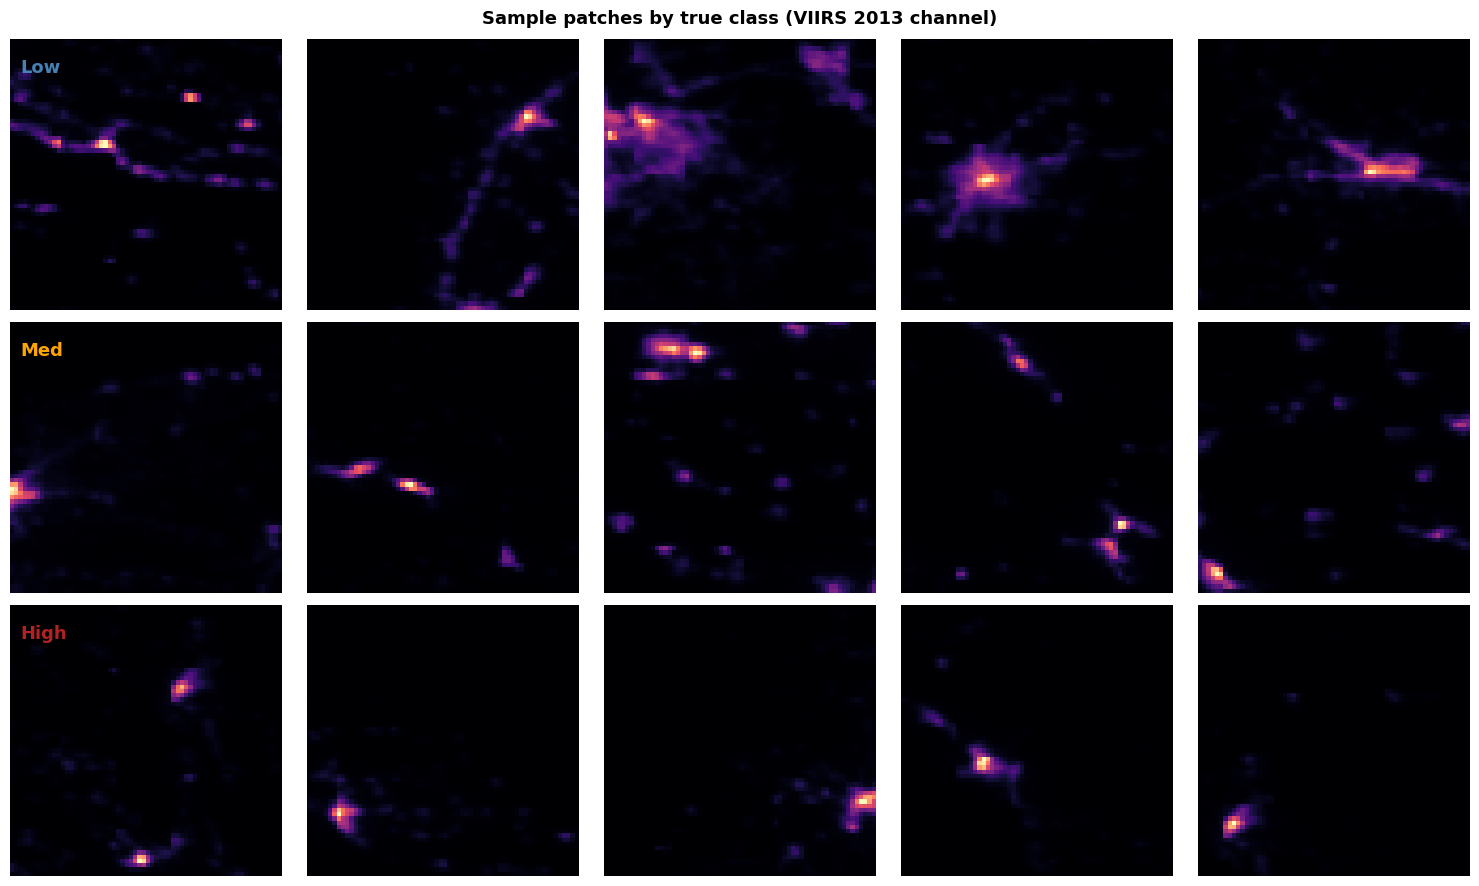

In [37]:
class_names  = ["Low", "Med", "High"]
class_colors = ["steelblue", "orange", "firebrick"]
n_per_class  = 5

all_p = np.concatenate([all_patches[c] for c in COUNTRIES])
all_l = np.concatenate([all_labels[c]  for c in COUNTRIES])

fig, axes = plt.subplots(3, n_per_class, figsize=(3 * n_per_class, 9))
fig.suptitle("Sample patches by true class (VIIRS 2013 channel)", fontsize=13, fontweight="bold")

np.random.seed(42)
for row, (cls, name, color) in enumerate(zip([0, 1, 2], class_names, class_colors)):
    idx    = np.where(all_l == cls)[0]
    chosen = np.random.choice(idx, size=n_per_class, replace=False)
    for col, patch_idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(all_p[patch_idx, 0], cmap="magma")
        ax.axis("off")
        if col == 0:
            ax.text(2, 4, name, color=color, fontsize=13, fontweight="bold", va="top")

plt.tight_layout()
plt.show()